# [[7,1,3]] Steane QSS — state overlap via SWAP test

This notebook follows the Steane encoder in Eq. (7) / Fig. 5 and exposes the **non-threshold access structure** directly.  Set `ERASED_SHARES` before building the circuit.  The notebook rejects an erased set that itself contains a minimal authorized set (or whose survivors are unauthorized), and it derives the syndrome correction table for every valid choice.

The paper's canonical examples are `E=(6,7)` (Fig. 5 / Table III) and `E=(5,6,7)` (Fig. 11 / Table IV).  The helper also supports the other correctable three- and four-share erasures.

**Execution controls:** choose `BACKEND_MODE = "ideal"`, `"fake_brisbane"`, or `"fake_torino"`. The fake modes use `AerSimulator.from_backend(...)` for local noisy simulation. `USE_M3=True` applies M3 readout mitigation to the final metric measurements and projects the resulting quasi-distribution to the nearest physical probability distribution (L2-norm). M3 does **not** retroactively correct the mid-circuit syndrome bits used for feed-forward.

**Must set up your authentication for access to actual quantum hardware**

PAPER: https://arxiv.org/abs/2410.11640 or https://www.mdpi.com/1099-4300/27/10/993

In [1]:
# The fake backends provide IBM device snapshots; Aer executes noisy simulations from them.
# %pip install "qiskit>=2.0" "qiskit[visualization]" "qiskit-aer>=0.17" "qiskit-ibm-runtime" "mthree>=3.0" matplotlib

In [2]:
from itertools import product, combinations
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.result import marginal_counts
from qiskit.quantum_info import Statevector, state_fidelity

np.set_printoptions(precision=6, suppress=True)

In [3]:
# -------------------- USER CONFIG --------------------
ERASED_SHARES = (6, 7)      # or another correctable set from the access-structure helper
THETA_DEG = 73.0
PHI_DEG = 121.0
SHOTS = 20_000              # 20,000 shots for SWAP-test jobs
OPTIMIZATION_LEVEL = 0      # 0, 1, 2, 3

# Execution / mitigation
BACKEND_MODE = "ideal"   # "ideal", "fake_brisbane", or "fake_torino"
USE_M3 = True
M3_CAL_SHOTS = 10_000
M3_CAL_METHOD = "independent"    # fast/suitable for simulator calibration
SEED_TRANSPILE = 12345
SEED_SIMULATOR = 12345
# -----------------------------------------------------
THETA = np.deg2rad(THETA_DEG)
PHI = np.deg2rad(PHI_DEG)


In [4]:
# Paper Fig. 5 / Sec. III B.  Secret enters/reappears on physical qubit 1 (index 0).
N = 7
OUTPUT_QUBIT = 0
SYNDROME_QUBITS = (1, 2, 3, 4, 5, 6)

# Reverse of the stabilizer-reduction sequence in Eq. (7), including the Z on q1
# visible at both ends of Figs. 5 and 11.
ENCODER_GATES = [
    ("z", 0),
    ("h", 4), ("h", 5), ("h", 6),
    ("cx", 0, 1), ("cx", 0, 2),
    ("cx", 6, 0), ("cx", 6, 1), ("cx", 6, 3),
    ("cx", 5, 0), ("cx", 5, 2), ("cx", 5, 3),
    ("cx", 4, 1), ("cx", 4, 2), ("cx", 4, 3),
]
DECODER_GATES = list(reversed(ENCODER_GATES))

ALL_SHARES = frozenset(range(1, 8))
STEANE_MINIMAL_AUTHORIZED = tuple(map(frozenset, [
    (1, 2, 3), (1, 4, 5), (1, 6, 7), (2, 4, 6),
    (2, 5, 7), (3, 4, 7), (3, 5, 6),
]))


def steane_is_authorized(shares):
    S = frozenset(shares)
    return any(A <= S for A in STEANE_MINIMAL_AUTHORIZED)


def steane_erasure_is_correctable(erased_shares):
    """For this pure-state QSS code, discarded E must be unauthorized and E^c authorized."""
    E = frozenset(erased_shares)
    if not E <= ALL_SHARES:
        return False
    survivors = ALL_SHARES - E
    return (not steane_is_authorized(E)) and steane_is_authorized(survivors)


def correctable_steane_erasures(size):
    return [c for c in combinations(sorted(ALL_SHARES), size)
            if steane_erasure_is_correctable(c)]


def validate_steane_erasure(erased_shares):
    E = tuple(sorted(set(erased_shares)))
    if len(E) != len(tuple(erased_shares)):
        raise ValueError("Do not repeat a share index.")
    if not set(E) <= ALL_SHARES:
        raise ValueError(f"Shares must be chosen from {sorted(ALL_SHARES)}")
    if not steane_erasure_is_correctable(E):
        survivors = tuple(sorted(ALL_SHARES - set(E)))
        raise ValueError(
            f"E={E} is not a correctable erasure set for the Steane QSS access structure. "
            f"Survivors are {survivors}. Use correctable_steane_erasures(len(E)) "
            "to list valid choices of the same size."
        )
    return E


def prepare_qubit_secret(qc, qubit, theta, phi):
    qc.rx(theta, qubit)
    qc.rz(phi, qubit)


In [5]:
PAULIS = "IXYZ"
XZ_TO_PAULI = {(0, 0): "I", (1, 0): "X", (0, 1): "Z", (1, 1): "Y"}


def _conj_h(x, z, q):
    x[q], z[q] = z[q], x[q]


def _conj_cx(x, z, c, t):
    # Clifford propagation, phases discarded.
    x[t] ^= x[c]
    z[c] ^= z[t]


def _conj_cz(x, z, a, b):
    z[a] ^= x[b]
    z[b] ^= x[a]


def propagate_pauli_through_decoder(n, error_ops, decoder_gates):
    """Propagate a Pauli supported on physical code qubits through U^†.

    error_ops is an iterable of (qubit_index, 'I'/'X'/'Y'/'Z').
    Only the binary symplectic label is needed; global phases are irrelevant.
    """
    x = [0] * n
    z = [0] * n
    for q, p in error_ops:
        if p in ("X", "Y"):
            x[q] ^= 1
        if p in ("Z", "Y"):
            z[q] ^= 1

    for gate in decoder_gates:
        kind = gate[0]
        if kind == "h":
            _conj_h(x, z, gate[1])
        elif kind == "cx":
            _conj_cx(x, z, gate[1], gate[2])
        elif kind == "cz":
            _conj_cz(x, z, gate[1], gate[2])
        elif kind in ("x", "z"):
            # Conjugation by X/Z changes at most a phase.
            pass
        else:
            raise ValueError(f"Unsupported Clifford gate in propagation list: {gate}")
    return x, z


def derive_erasure_correction_lookup(n, erased_zero_based, decoder_gates,
                                     syndrome_qubits, output_qubit):
    """Return syndrome-int -> logical Pauli correction for a known erasure set.

    Each syndrome clbit i is paired with syndrome_qubits[i], so the integer used
    by QuantumCircuit.if_test is sum(bit_i * 2**i).
    """
    by_syndrome = {}
    erased_zero_based = tuple(erased_zero_based)

    for pattern in product(PAULIS, repeat=len(erased_zero_based)):
        error_ops = list(zip(erased_zero_based, pattern))
        x, z = propagate_pauli_through_decoder(n, error_ops, decoder_gates)
        syndrome_bits = tuple(x[q] for q in syndrome_qubits)
        syndrome_int = sum(bit << i for i, bit in enumerate(syndrome_bits))
        logical = XZ_TO_PAULI[(x[output_qubit], z[output_qubit])]
        by_syndrome.setdefault(syndrome_int, set()).add(logical)

    collisions = {s: ops for s, ops in by_syndrome.items() if len(ops) != 1}
    if collisions:
        raise ValueError(
            "This erasure set is not correctable by the selected code/recovery. "
            f"Ambiguous syndrome(s): {collisions}"
        )
    return {s: next(iter(ops)) for s, ops in by_syndrome.items()}


def syndrome_tuple_to_int(bits):
    return sum(int(bit) << i for i, bit in enumerate(bits))


def append_gate_list(qc, qreg, gates):
    for gate in gates:
        kind = gate[0]
        if kind == "h":
            qc.h(qreg[gate[1]])
        elif kind == "x":
            qc.x(qreg[gate[1]])
        elif kind == "z":
            qc.z(qreg[gate[1]])
        elif kind == "cx":
            qc.cx(qreg[gate[1]], qreg[gate[2]])
        elif kind == "cz":
            qc.cz(qreg[gate[1]], qreg[gate[2]])
        else:
            raise ValueError(gate)


def apply_feedforward_corrections(qc, syndrome_register, output_qubit, lookup):
    """Paper-style mid-circuit measurement + classical feed-forward."""
    for syndrome_int, pauli in sorted(lookup.items()):
        if pauli == "I":
            continue
        with qc.if_test((syndrome_register, syndrome_int)):
            getattr(qc, pauli.lower())(output_qubit)


def make_execution_backend(mode=BACKEND_MODE):
    """Return an Aer execution backend.

    Modes
    -----
    ideal          : noiseless AerSimulator
    fake_brisbane  : Aer noise model / coupling / basis derived from FakeBrisbane
    fake_torino    : Aer noise model / coupling / basis derived from FakeTorino

    For the fake modes, AerSimulator.from_backend(...) copies the fake device
    snapshot into a local noisy simulator.  Circuits are transpiled against this
    simulator, so the final physical-qubit mapping can be passed directly to M3.
    """
    mode = mode.lower()
    if mode == "ideal":
        return AerSimulator(), "ideal AerSimulator"

    try:
        from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeTorino
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Fake backends require qiskit-ibm-runtime. Uncomment the %pip install cell."
        ) from exc

    if mode == "fake_brisbane":
        snapshot = FakeBrisbane()
    elif mode == "fake_torino":
        snapshot = FakeTorino()
    else:
        raise ValueError(
            "BACKEND_MODE must be 'ideal', 'fake_brisbane', or 'fake_torino'."
        )
    return AerSimulator.from_backend(snapshot), snapshot.name


EXECUTION_BACKEND, BACKEND_LABEL = make_execution_backend()
print("Execution backend:", BACKEND_LABEL)
print("M3 enabled:", USE_M3)


def run_counts(circuit, shots=20000, optimization_level=0, backend=None):
    backend = EXECUTION_BACKEND if backend is None else backend
    compiled = transpile(
        circuit,
        backend,
        optimization_level=optimization_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    result = backend.run(
        compiled,
        shots=shots,
        seed_simulator=SEED_SIMULATOR,
    ).result()
    return compiled, result.get_counts()


def _m3_module():
    try:
        import mthree
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "USE_M3=True requires mthree. Uncomment the %pip install cell."
        ) from exc
    return mthree


def selected_raw_marginal(counts, circuit, clbits):
    indices = [circuit.find_bit(c).index for c in clbits]
    return marginal_counts(counts, indices=indices)


def m3_mitigated_marginal(compiled, counts, original_circuit, clbits, backend=None):
    """M3-correct only the requested *final metric* bits.

    This intentionally does not attempt to change the single-shot syndrome values
    that drove mid-circuit feed-forward. M3 can correct ensemble measurement
    statistics, but not a classical decision that already happened during a shot.
    """
    mthree = _m3_module()
    backend = EXECUTION_BACKEND if backend is None else backend
    indices = [original_circuit.find_bit(c).index for c in clbits]
    full_mapping = mthree.utils.final_measurement_mapping(compiled)
    marginal_raw, marginal_mapping = mthree.utils.marginal_distribution(
        counts, indices, full_mapping
    )
    mit = mthree.M3Mitigation(backend)
    mit.cals_from_system(
        marginal_mapping,
        shots=M3_CAL_SHOTS,
        method=M3_CAL_METHOD,
        async_cal=False,
    )
    quasi = mit.apply_correction(marginal_raw, marginal_mapping)
    # Maps M3 quasi-probabilities to the closest probability
    # distribution in L2 norm before reporting probabilities/fidelities.
    probs = quasi.nearest_probability_distribution()
    return marginal_raw, quasi, probs, marginal_mapping


def probability_zero_from_distribution(dist):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0", 0.0) / total)


def probability_all_zero_from_distribution(dist, nbits):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0" * nbits, 0.0) / total)


Execution backend: ideal AerSimulator
M3 enabled: True


In [6]:
print("Minimal authorized triples Γ_m:")
print([tuple(sorted(x)) for x in STEANE_MINIMAL_AUTHORIZED])
print("\nCorrectable size-3 erasures (28 total):")
print(correctable_steane_erasures(3))
print("\nCorrectable size-4 erasures (7 total):")
print(correctable_steane_erasures(4))

ERASED_SHARES = validate_steane_erasure(ERASED_SHARES)
erased0 = tuple(s - 1 for s in ERASED_SHARES)
lookup = derive_erasure_correction_lookup(
    N, erased0, DECODER_GATES, SYNDROME_QUBITS, OUTPUT_QUBIT
)
print("\nSelected E:", ERASED_SHARES)
print("Survivors:", tuple(sorted(ALL_SHARES - set(ERASED_SHARES))))
print("Reachable syndromes:", len(lookup), "of 64")

# Canonical paper checks.
paper_two = derive_erasure_correction_lookup(
    N, (5, 6), DECODER_GATES, SYNDROME_QUBITS, OUTPUT_QUBIT
)
assert paper_two[syndrome_tuple_to_int((0, 1, 1, 0, 0, 0))] == "X"  # I6 X7
paper_three = derive_erasure_correction_lookup(
    N, (4, 5, 6), DECODER_GATES, SYNDROME_QUBITS, OUTPUT_QUBIT
)
assert paper_three[syndrome_tuple_to_int((1, 1, 1, 0, 0, 0))] == "I"  # X5 I6 I7


Minimal authorized triples Γ_m:
[(1, 2, 3), (1, 4, 5), (1, 6, 7), (2, 4, 6), (2, 5, 7), (3, 4, 7), (3, 5, 6)]

Correctable size-3 erasures (28 total):
[(1, 2, 4), (1, 2, 5), (1, 2, 6), (1, 2, 7), (1, 3, 4), (1, 3, 5), (1, 3, 6), (1, 3, 7), (1, 4, 6), (1, 4, 7), (1, 5, 6), (1, 5, 7), (2, 3, 4), (2, 3, 5), (2, 3, 6), (2, 3, 7), (2, 4, 5), (2, 4, 7), (2, 5, 6), (2, 6, 7), (3, 4, 5), (3, 4, 6), (3, 5, 7), (3, 6, 7), (4, 5, 6), (4, 5, 7), (4, 6, 7), (5, 6, 7)]

Correctable size-4 erasures (7 total):
[(1, 2, 4, 7), (1, 2, 5, 6), (1, 3, 4, 6), (1, 3, 5, 7), (2, 3, 4, 5), (2, 3, 6, 7), (4, 5, 6, 7)]

Selected E: (6, 7)
Survivors: (1, 2, 3, 4, 5)
Reachable syndromes: 16 of 64


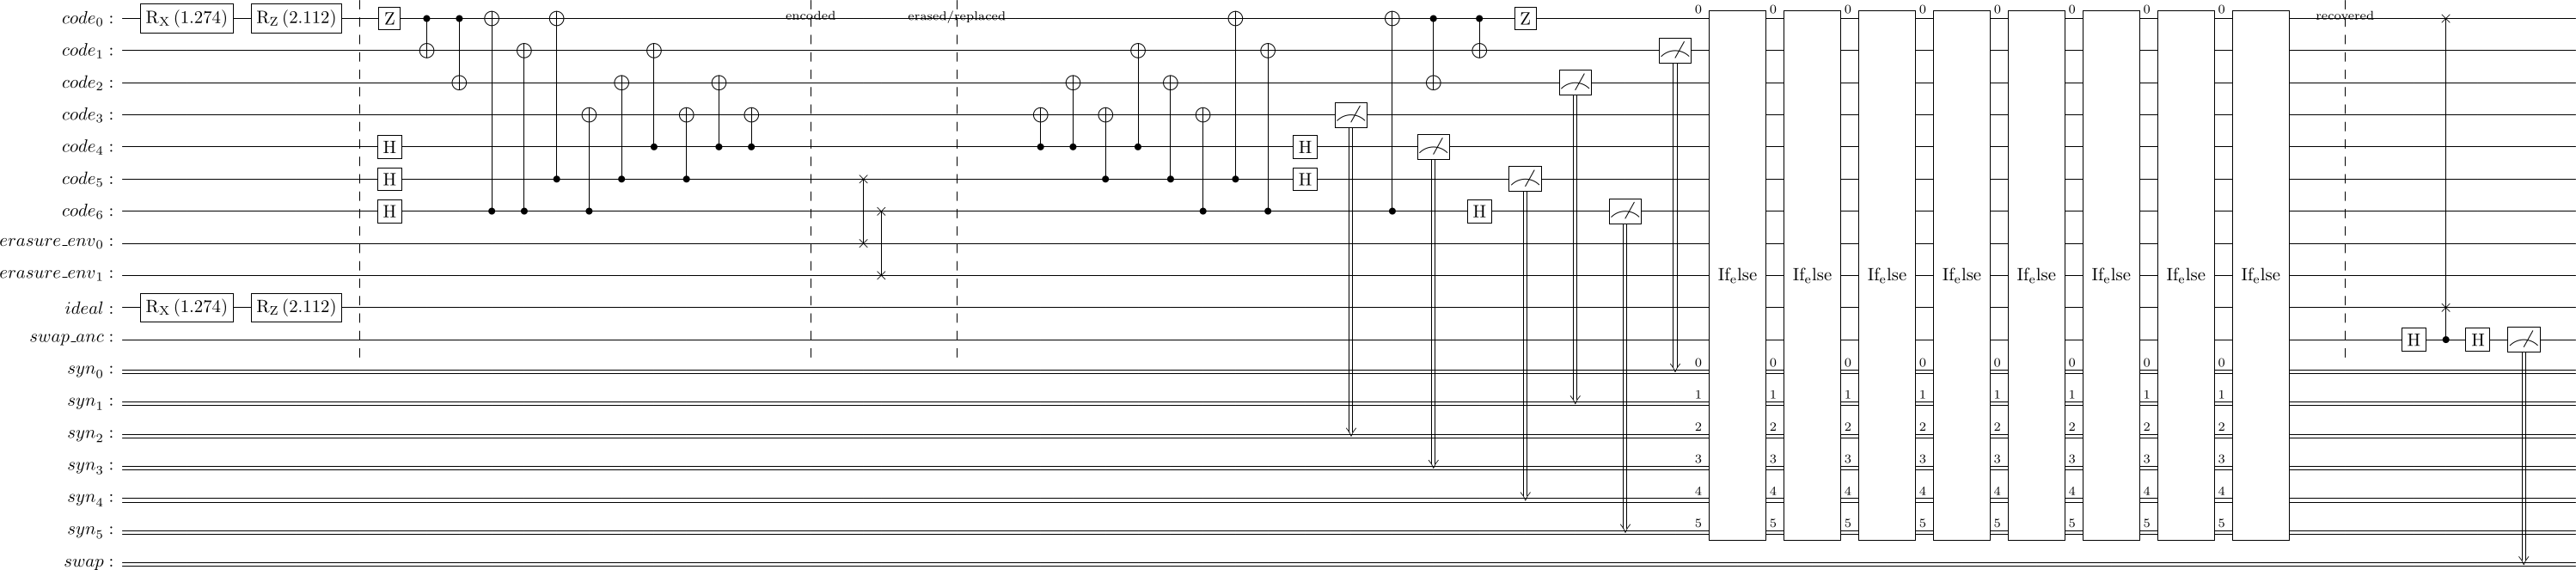

In [7]:
def build_overlap_circuit(erased_shares=ERASED_SHARES, theta=THETA, phi=PHI):
    erased_shares = validate_steane_erasure(erased_shares)
    erased0 = tuple(s - 1 for s in erased_shares)
    lookup = derive_erasure_correction_lookup(
        N, erased0, DECODER_GATES, SYNDROME_QUBITS, OUTPUT_QUBIT
    )

    code_q = QuantumRegister(7, "code")
    fresh = QuantumRegister(len(erased0), "erasure_env")
    ideal = QuantumRegister(1, "ideal")
    swap_anc = QuantumRegister(1, "swap_anc")
    syn = ClassicalRegister(6, "syn")
    metric = ClassicalRegister(1, "swap")
    qc = QuantumCircuit(code_q, fresh, ideal, swap_anc, syn, metric)

    prepare_qubit_secret(qc, code_q[OUTPUT_QUBIT], theta, phi)
    prepare_qubit_secret(qc, ideal[0], theta, phi)
    qc.barrier()
    append_gate_list(qc, code_q, ENCODER_GATES)
    qc.barrier(label="encoded")

    for anc, q in zip(fresh, erased0):
        qc.swap(anc, code_q[q])
    qc.barrier(label="erased/replaced")

    append_gate_list(qc, code_q, DECODER_GATES)
    for i, q in enumerate(SYNDROME_QUBITS):
        qc.measure(code_q[q], syn[i])
    apply_feedforward_corrections(qc, syn, code_q[OUTPUT_QUBIT], lookup)
    qc.barrier(label="recovered")

    qc.h(swap_anc[0])
    qc.cswap(swap_anc[0], code_q[OUTPUT_QUBIT], ideal[0])
    qc.h(swap_anc[0])
    qc.measure(swap_anc[0], metric[0])
    return qc, metric


qc, metric = build_overlap_circuit()
display(qc.draw(output='latex', cregbundle=False))

In [8]:
compiled, counts = run_counts(qc, shots=SHOTS, optimization_level=OPTIMIZATION_LEVEL)
raw_metric = selected_raw_marginal(counts, qc, [metric[0]])
p0_raw = probability_zero_from_distribution(raw_metric)
overlap_raw = np.clip(2 * p0_raw - 1, 0.0, 1.0)

print("Backend:", BACKEND_LABEL)
print("Raw SWAP-test pass probability:", p0_raw)
print("Raw Inferred state overlap/fidelity:", overlap_raw)
print("Raw metric counts:", raw_metric)

if USE_M3:
    _, quasi, m3_probs, mapping = m3_mitigated_marginal(
        compiled, counts, qc, [metric[0]]
    )
    p0_m3 = probability_zero_from_distribution(m3_probs)
    overlap_m3 = np.clip(2 * p0_m3 - 1, 0.0, 1.0)
    print("M3 physical-qubit mapping:", mapping)
    print("M3 SWAP-test pass probability:", p0_m3)
    print("M3 Inferred state overlap/fidelity:", overlap_m3)
    print("M3 nearest probability distribution:", m3_probs)

print("Circuit depth (logical / transpiled):", qc.depth(), "/", compiled.depth())


Backend: ideal AerSimulator
Raw SWAP-test pass probability: 1.0
Raw Inferred state overlap/fidelity: 1.0
Raw metric counts: {'0': 20000}
M3 physical-qubit mapping: {0: 10}
M3 SWAP-test pass probability: 1.0
M3 Inferred state overlap/fidelity: 1.0
M3 nearest probability distribution: {'0': np.float32(1.0)}
Circuit depth (logical / transpiled): 31 / 31


### Noisy backend + M3 notes

`fake_brisbane` and `fake_torino` are the two noisy fake-backend choices used for comparisons. The circuit is transpiled to the selected fake device snapshot and executed locally with Aer noise copied from that snapshot. M3 is calibrated on the **physical qubits that hold the final measured metric bits after transpilation**, obtained from `mthree.utils.final_measurement_mapping`. The returned quasi-probabilities are converted to the nearest probability distribution before the SWAP-test probability is calculated.

For the qubit MCM decoders, readout mitigation only changes the ensemble statistics reported at the end. It cannot undo a wrong syndrome measurement that already caused a conditional correction during that shot.
